# Statistical Tests
**Author:** Ilhan Haniff  
**Description:** This notebook runs statistical tests to formally confirm the findings from `analysis.ipynb`. All comparisons use the same matched seasonal windows: **April 7 – December 31, 2024 (pre)** vs. **April 7 – December 31, 2025 (post)**.

**Inputs:**
- `data/cad_clean_2015_2025.csv` — Cleaned Eugene CAD data
- `data/spd_clean_2015_2025.csv` — Cleaned SPD Responding Units data

**Tests:**
1. Independent samples t-test: EPD daily call volume (2024 vs. 2025)
2. Chi-square test: Agency share of total calls (pre vs. post)
3. Independent samples t-test: Springfield CAHOOTS daily call volume (2024 vs. 2025)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')

## 2. Load Cleaned Datasets

In [2]:
cad = pd.read_csv(os.path.join('data', 'cad_clean_2015_2025.csv'), parse_dates=['calltime'])
spd = pd.read_csv(os.path.join('data', 'spd_clean_2015_2025.csv'), parse_dates=['calltime'])

print(f'CAD shape: {cad.shape}')
print(f'SPD shape: {spd.shape}')

CAD shape: (1446014, 9)
SPD shape: (567655, 9)


## 3. Define Matched Seasonal Windows

In [3]:
# Same seasonal window — one year apart
pre_start  = pd.Timestamp('2024-04-07')
pre_end    = pd.Timestamp('2024-12-31')
post_start = pd.Timestamp('2025-04-07')
post_end   = pd.Timestamp('2025-12-31')

print(f'Pre window:  {pre_start.date()} to {pre_end.date()}')
print(f'Post window: {post_start.date()} to {post_end.date()}')

Pre window:  2024-04-07 to 2024-12-31
Post window: 2025-04-07 to 2025-12-31


## 4. Helper Function
- Provided to help intepret p-values. 

In [4]:
def interpret(p, alpha=0.05):
    """
    Returns a plain English interpretation of a p-value.
    """
    if p < alpha:
        return f'p = {p:.4f} < {alpha} → STATISTICALLY SIGNIFICANT difference'
    else:
        return f'p = {p:.4f} >= {alpha} → NO statistically significant difference'

---
## Test 1: Independent Samples T-Test — EPD Daily Call Volume

**Question:** Did average daily EPD call volume change significantly after CAHOOTS discontinued?

**H₀ (Null hypothesis):** There is no difference in mean daily EPD call volume between the 2024 and 2025 windows.

**H₁ (Alternative hypothesis):** There is a significant difference in mean daily EPD call volume between the two windows.

**Method:** `scipy.stats.ttest_ind()`  
**Input:** Daily EPD call counts for each window  
**Output:** t-statistic, p-value, interpretation

In [5]:
# Isolate EPD calls for each window
epd_pre = cad[
    (cad['unit_type'] == 'EPD') &
    (cad['calltime'] >= pre_start) &
    (cad['calltime'] <= pre_end)
]
epd_post = cad[
    (cad['unit_type'] == 'EPD') &
    (cad['calltime'] >= post_start) &
    (cad['calltime'] <= post_end)
]

# Compute daily call counts
epd_pre_daily  = epd_pre.groupby(epd_pre['calltime'].dt.date).size()
epd_post_daily = epd_post.groupby(epd_post['calltime'].dt.date).size()

print(f'EPD pre  — n days: {len(epd_pre_daily)}, mean: {epd_pre_daily.mean():.1f}, std: {epd_pre_daily.std():.1f}')
print(f'EPD post — n days: {len(epd_post_daily)}, mean: {epd_post_daily.mean():.1f}, std: {epd_post_daily.std():.1f}')

EPD pre  — n days: 268, mean: 230.4, std: 40.3
EPD post — n days: 268, mean: 227.4, std: 40.1


In [6]:
# Check normality assumption using Shapiro-Wilk test
# t-test assumes approximate normality; with large n this is generally satisfied
stat_pre,  p_norm_pre  = stats.shapiro(epd_pre_daily)
stat_post, p_norm_post = stats.shapiro(epd_post_daily)

print(f'Shapiro-Wilk (pre):  W={stat_pre:.4f},  p={p_norm_pre:.4f}')
print(f'Shapiro-Wilk (post): W={stat_post:.4f}, p={p_norm_post:.4f}')
print('\nNote: if p < 0.05 distributions are non-normal; consider Mann-Whitney U test instead')

Shapiro-Wilk (pre):  W=0.9903,  p=0.0723
Shapiro-Wilk (post): W=0.9955, p=0.6232

Note: if p < 0.05 distributions are non-normal; consider Mann-Whitney U test instead


In [7]:
# Run independent samples t-test
t_stat, p_val = stats.ttest_ind(epd_pre_daily, epd_post_daily)

print('=== Test 1: EPD Daily Call Volume ===')
print(f't-statistic: {t_stat:.4f}')
print(interpret(p_val))
print(f'\nMean difference: {epd_pre_daily.mean() - epd_post_daily.mean():.1f} calls/day')
print(f'Percentage change: {((epd_post_daily.mean() - epd_pre_daily.mean()) / epd_pre_daily.mean()) * 100:+.1f}%')

=== Test 1: EPD Daily Call Volume ===
t-statistic: 0.8545
p = 0.3932 >= 0.05 → NO statistically significant difference

Mean difference: 3.0 calls/day
Percentage change: -1.3%


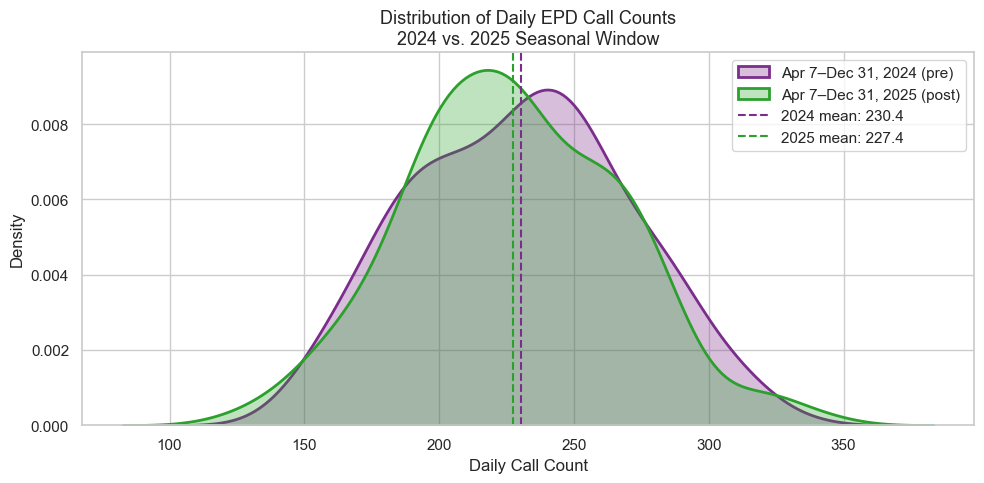

In [9]:
# Visualize distributions of daily EPD call counts
fig, ax = plt.subplots(figsize=(10, 5))

for daily, label, color in zip(
    [epd_pre_daily, epd_post_daily],
    ['Apr 7–Dec 31, 2024 (pre)', 'Apr 7–Dec 31, 2025 (post)'],
    ['#7B2D8B', '#2CA02C']
):
    sns.kdeplot(daily, ax=ax, label=label, color=color,
                linewidth=2, fill=True, alpha=0.3)

ax.axvline(epd_pre_daily.mean(), color='#7B2D8B', linestyle='--',
           linewidth=1.5, label=f'2024 mean: {epd_pre_daily.mean():.1f}')
ax.axvline(epd_post_daily.mean(), color='#2CA02C', linestyle='--',
           linewidth=1.5, label=f'2025 mean: {epd_post_daily.mean():.1f}')

ax.set_title('Distribution of Daily EPD Call Counts\n2024 vs. 2025 Seasonal Window', fontsize=13)
ax.set_xlabel('Daily Call Count')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('figures/test1_epd_daily_distribution.png', dpi=150)
plt.show()

---
## Test 2: Chi-Square Test — Agency Share of Total Calls

**Question:** Did the distribution of calls across agencies change significantly after CAHOOTS discontinued?

**H₀ (Null hypothesis):** The distribution of calls across agency types is the same in both windows.

**H₁ (Alternative hypothesis):** The distribution of calls across agency types changed significantly between the two windows.

**Method:** `scipy.stats.chi2_contingency()`  
**Input:** Contingency table of call counts by agency and period  
**Output:** Chi-square statistic, p-value, degrees of freedom, interpretation

In [10]:
# Build contingency table: rows = agency, columns = period
cad_pre_window = cad[
    (cad['calltime'] >= pre_start) &
    (cad['calltime'] <= pre_end)
]
cad_post_window = cad[
    (cad['calltime'] >= post_start) &
    (cad['calltime'] <= post_end)
]

pre_counts  = cad_pre_window['unit_type'].value_counts()
post_counts = cad_post_window['unit_type'].value_counts()

# Align on same index
all_types = sorted(set(pre_counts.index) | set(post_counts.index))
pre_counts  = pre_counts.reindex(all_types, fill_value=0)
post_counts = post_counts.reindex(all_types, fill_value=0)

contingency_table = pd.DataFrame({
    'Pre (2024)':  pre_counts,
    'Post (2025)': post_counts
})

print('Contingency Table (call counts by agency and period):')
print(contingency_table)
print(f'\nTotal pre:  {pre_counts.sum():,}')
print(f'Total post: {post_counts.sum():,}')

Contingency Table (call counts by agency and period):
           Pre (2024)  Post (2025)
unit_type                         
CAHOOTS         12086            7
EPD             61735        60939
UNKNOWN         25146        21879

Total pre:  98,967
Total post: 82,825


In [11]:
# Run chi-square test
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print('=== Test 2: Agency Share of Total Calls ===')
print(f'Chi-square statistic: {chi2:.4f}')
print(f'Degrees of freedom:   {dof}')
print(interpret(p_val_chi2))

print('\nExpected counts table:')
print(pd.DataFrame(expected, index=all_types,
                   columns=['Expected Pre', 'Expected Post']).round(1))

=== Test 2: Agency Share of Total Calls ===
Chi-square statistic: 10950.1774
Degrees of freedom:   2
p = 0.0000 < 0.05 → STATISTICALLY SIGNIFICANT difference

Expected counts table:
         Expected Pre  Expected Post
CAHOOTS        6583.4         5509.6
EPD           66783.3        55890.7
UNKNOWN       25600.3        21424.7


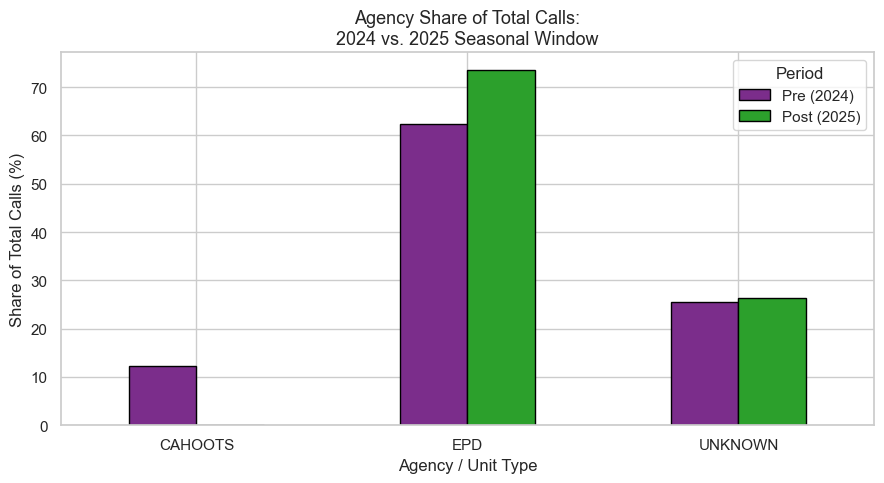

In [12]:
# Visualize agency share as proportions
share_table = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
share_table.plot(kind='bar', ax=ax,
                 color=['#7B2D8B', '#2CA02C'],
                 edgecolor='black')

ax.set_title('Agency Share of Total Calls:\n2024 vs. 2025 Seasonal Window', fontsize=13)
ax.set_xlabel('Agency / Unit Type')
ax.set_ylabel('Share of Total Calls (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Period')
plt.tight_layout()
plt.savefig('figures/test2_agency_share.png', dpi=150)
plt.show()

---
## Test 3: Independent Samples T-Test — Springfield CAHOOTS Daily Call Volume

**Question:** Did Springfield CAHOOTS daily call volume change significantly between the same windows?

**H₀ (Null hypothesis):** There is no difference in mean daily Springfield CAHOOTS call volume between the 2024 and 2025 windows.

**H₁ (Alternative hypothesis):** There is a significant difference.

**Interpretation:** If this test is NOT significant while Eugene's patterns changed dramatically, it validates Springfield as a stable control — confirming the Eugene changes were driven by the discontinuation rather than broader trends.

**Method:** `scipy.stats.ttest_ind()`  
**Input:** Daily Springfield CAHOOTS call counts for each window  
**Output:** t-statistic, p-value, interpretation

In [13]:
# Isolate Springfield CAHOOTS calls for each window
spd_pre = spd[
    (spd['unit_type'] == 'CAHOOTS') &
    (spd['calltime'] >= pre_start) &
    (spd['calltime'] <= pre_end)
]
spd_post = spd[
    (spd['unit_type'] == 'CAHOOTS') &
    (spd['calltime'] >= post_start) &
    (spd['calltime'] <= post_end)
]

# Compute daily call counts
spd_pre_daily  = spd_pre.groupby(spd_pre['calltime'].dt.date).size()
spd_post_daily = spd_post.groupby(spd_post['calltime'].dt.date).size()

print(f'SPD CAHOOTS pre  — n days: {len(spd_pre_daily)}, mean: {spd_pre_daily.mean():.1f}, std: {spd_pre_daily.std():.1f}')
print(f'SPD CAHOOTS post — n days: {len(spd_post_daily)}, mean: {spd_post_daily.mean():.1f}, std: {spd_post_daily.std():.1f}')

SPD CAHOOTS pre  — n days: 266, mean: 8.5, std: 3.2
SPD CAHOOTS post — n days: 231, mean: 7.1, std: 2.8


In [14]:
# Check normality
stat_pre,  p_norm_pre  = stats.shapiro(spd_pre_daily)
stat_post, p_norm_post = stats.shapiro(spd_post_daily)

print(f'Shapiro-Wilk (pre):  W={stat_pre:.4f},  p={p_norm_pre:.4f}')
print(f'Shapiro-Wilk (post): W={stat_post:.4f}, p={p_norm_post:.4f}')

Shapiro-Wilk (pre):  W=0.9735,  p=0.0001
Shapiro-Wilk (post): W=0.9769, p=0.0008


In [15]:
# Run independent samples t-test
t_stat_spd, p_val_spd = stats.ttest_ind(spd_pre_daily, spd_post_daily)

print('=== Test 3: Springfield CAHOOTS Daily Call Volume ===')
print(f't-statistic: {t_stat_spd:.4f}')
print(interpret(p_val_spd))
print(f'\nMean difference: {spd_pre_daily.mean() - spd_post_daily.mean():.1f} calls/day')
print(f'Percentage change: {((spd_post_daily.mean() - spd_pre_daily.mean()) / spd_pre_daily.mean()) * 100:+.1f}%')

=== Test 3: Springfield CAHOOTS Daily Call Volume ===
t-statistic: 5.3538
p = 0.0000 < 0.05 → STATISTICALLY SIGNIFICANT difference

Mean difference: 1.5 calls/day
Percentage change: -17.1%


In [16]:
# Mann-Whitney U as non-parametric alternative
u_stat_spd, p_mw_spd = stats.mannwhitneyu(spd_pre_daily, spd_post_daily, alternative='two-sided')

print('=== Mann-Whitney U Test (non-parametric alternative) ===')
print(f'U-statistic: {u_stat_spd:.4f}')
print(interpret(p_mw_spd))

=== Mann-Whitney U Test (non-parametric alternative) ===
U-statistic: 38644.0000
p = 0.0000 < 0.05 → STATISTICALLY SIGNIFICANT difference


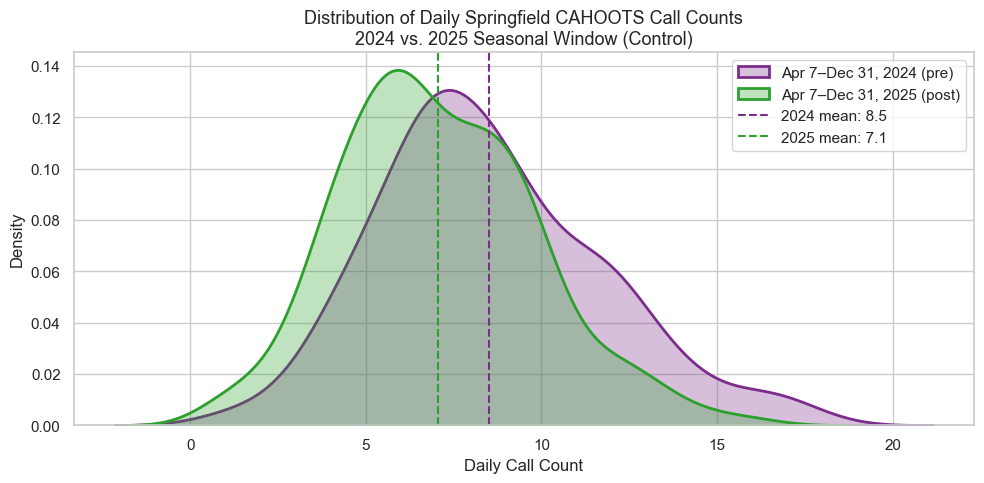

In [17]:
# Visualize distributions of daily Springfield CAHOOTS call counts
fig, ax = plt.subplots(figsize=(10, 5))

for daily, label, color in zip(
    [spd_pre_daily, spd_post_daily],
    ['Apr 7–Dec 31, 2024 (pre)', 'Apr 7–Dec 31, 2025 (post)'],
    ['#7B2D8B', '#2CA02C']
):
    sns.kdeplot(daily, ax=ax, label=label, color=color,
                linewidth=2, fill=True, alpha=0.3)

ax.axvline(spd_pre_daily.mean(), color='#7B2D8B', linestyle='--',
           linewidth=1.5, label=f'2024 mean: {spd_pre_daily.mean():.1f}')
ax.axvline(spd_post_daily.mean(), color='#2CA02C', linestyle='--',
           linewidth=1.5, label=f'2025 mean: {spd_post_daily.mean():.1f}')

ax.set_title('Distribution of Daily Springfield CAHOOTS Call Counts\n2024 vs. 2025 Seasonal Window (Control)', fontsize=13)
ax.set_xlabel('Daily Call Count')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('figures/test3_spd_cahoots_daily_distribution.png', dpi=150)
plt.show()

---
## 5. Summary of Results

In [18]:
print('=' * 65)
print('STATISTICAL TESTS SUMMARY')
print('=' * 65)
print(f"""
Test 1 — EPD Daily Call Volume (t-test)
  Pre mean:  {epd_pre_daily.mean():.1f} calls/day
  Post mean: {epd_post_daily.mean():.1f} calls/day
  t = {t_stat:.4f}, {interpret(p_val)}

Test 2 — Agency Share of Total Calls (chi-square)
  Chi2 = {chi2:.4f}, df = {dof}
  {interpret(p_val_chi2)}

Test 3 — Springfield CAHOOTS Daily Call Volume (t-test)
  Pre mean:  {spd_pre_daily.mean():.1f} calls/day
  Post mean: {spd_post_daily.mean():.1f} calls/day
  t = {t_stat_spd:.4f}, {interpret(p_val_spd)}
""")
print('=' * 65)

STATISTICAL TESTS SUMMARY

Test 1 — EPD Daily Call Volume (t-test)
  Pre mean:  230.4 calls/day
  Post mean: 227.4 calls/day
  t = 0.8545, p = 0.3932 >= 0.05 → NO statistically significant difference

Test 2 — Agency Share of Total Calls (chi-square)
  Chi2 = 10950.1774, df = 2
  p = 0.0000 < 0.05 → STATISTICALLY SIGNIFICANT difference

Test 3 — Springfield CAHOOTS Daily Call Volume (t-test)
  Pre mean:  8.5 calls/day
  Post mean: 7.1 calls/day
  t = 5.3538, p = 0.0000 < 0.05 → STATISTICALLY SIGNIFICANT difference

